In [6]:
import xarray as xr
import numpy as np
from pathlib import Path
import glob

# ============================================================
# Settings
# ============================================================
IN_DIR = Path(
    "/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/"
    "historical/r1i1p1f1/Amon/tas/gn/latest"
)

FHIST_TAS = Path(
    "/nird/home/yongyub/kimyy/Dropbox/source/python/all/AERA/examples/"
    "example2_data/HadCRUT.5.0.1.0.analysis.summary_series.global.annual.nc"
)

files = sorted(glob.glob(str(IN_DIR / "tas_Amon_NorESM2-LM_historical_r1i1p1f1_gn_*.nc")))

files_1850_1899 = [
    f for f in files
    if any(tag in Path(f).name for tag in [
        "185001-185912",
        "186001-186912",
        "187001-187912",
        "188001-188912",
        "189001-189912",
    ])
]

print("Files used:")
for f in files_1850_1899:
    print(f)

# ============================================================
# NorESM global mean TAS, 1850-1899
# ============================================================
ds = xr.open_mfdataset(
    files_1850_1899,
    combine="by_coords",
    decode_times=True,
    use_cftime=True,
)

tas = ds["tas"]  # K, dimensions: time, lat, lon

lat_bnds = ds["lat_bnds"]
rad = np.pi / 180.0
lat_weights = np.sin(lat_bnds.isel(bnds=1) * rad) - np.sin(lat_bnds.isel(bnds=0) * rad)
area_weights = lat_weights.broadcast_like(tas.isel(time=0))

tas_gm_mon = tas.weighted(area_weights).mean(dim=("lat", "lon"))

month_length = tas_gm_mon["time"].dt.days_in_month
tas_model_ref = tas_gm_mon.weighted(month_length).mean(dim="time")

# ============================================================
# HadCRUT tas_mean anomaly, 1850-1899
# ============================================================
ds_had = xr.open_dataset(FHIST_TAS)

had_year = ds_had["time"].dt.year
had = ds_had["tas_mean"]

had_1850_1899 = had.where((had_year >= 1850) & (had_year <= 1899), drop=True)
had_ref_anom = had_1850_1899.mean("time")

# ============================================================
# Bias correction
# ============================================================
# HadCRUT tas_mean is anomaly relative to its own baseline.
# Bias-corrected model absolute reference = model absolute reference + HadCRUT reference anomaly
tas_model_ref_bc = tas_model_ref + had_ref_anom

print("\n====================================")
print("Global area-weighted mean TAS")
print("Period: 1850-1899")
print(f"NorESM raw mean TAS        = {float(tas_model_ref.values):.6f} K")
print(f"HadCRUT mean anomaly       = {float(had_ref_anom.values):.6f} K")
print(f"Bias-corrected mean TAS    = {float(tas_model_ref_bc.values):.6f} K")
print("====================================")

Files used:
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/historical/r1i1p1f1/Amon/tas/gn/latest/tas_Amon_NorESM2-LM_historical_r1i1p1f1_gn_185001-185912.nc
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/historical/r1i1p1f1/Amon/tas/gn/latest/tas_Amon_NorESM2-LM_historical_r1i1p1f1_gn_186001-186912.nc
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/historical/r1i1p1f1/Amon/tas/gn/latest/tas_Amon_NorESM2-LM_historical_r1i1p1f1_gn_187001-187912.nc
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/historical/r1i1p1f1/Amon/tas/gn/latest/tas_Amon_NorESM2-LM_historical_r1i1p1f1_gn_188001-188912.nc
/nird/datapeak/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/historical/r1i1p1f1/Amon/tas/gn/latest/tas_Amon_NorESM2-LM_historical_r1i1p1f1_gn_189001-189912.nc

Global area-weighted mean TAS
Period: 1850-1899
NorESM raw mean TAS        = 287.652111 K
HadCRUT mean anomaly       = -0.358943 K
Bias-corrected mean TAS    = 287.293169 K


=== File check ===
csv         : True  /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/AERA/output/AERA_T_20_2019.csv
ann_dat     : True  /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/AERA/output/AERA_T_20_ann_tas_co2_ems.dat
meta_nc     : True  /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/AERA/output/AERA_T_20_meta_1782898285.nc
scalar      : True  /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/AERA/output/AERA_T_20_meta_1782898285.nc.scalar.csv
timeseries  : True  /nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/AERA/output/AERA_T_20_meta_1782898285.nc.timeseries.csv

=== AERA csv ===


,year,ff_emission
0,2020,9.893924
1,2021,9.887801
2,2022,9.796968
3,2023,9.718929
4,2024,9.656755


Index(['year', 'ff_emission'], dtype='object')


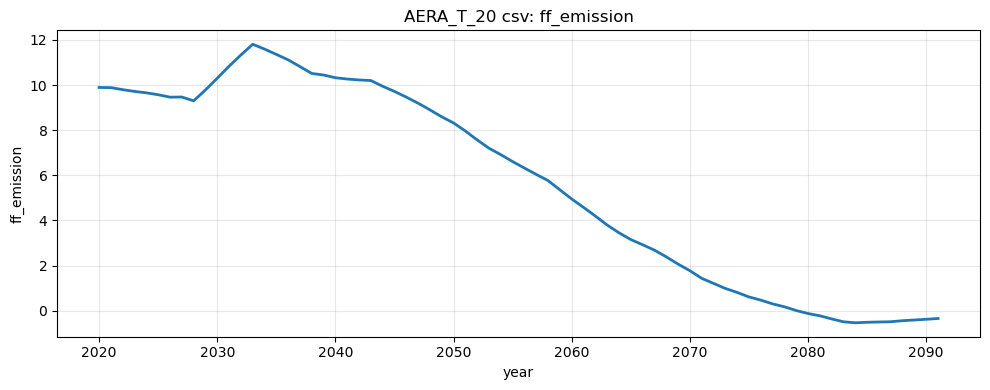


=== Annual dat ===


,year,ann_tas,ann_co2,ann_ems
0,1850.0,-0.417659,NaN,0.054
1,1851.0,-0.233350,NaN,0.054
2,1852.0,-0.229399,NaN,0.057
3,1853.0,-0.270354,NaN,0.059
4,1854.0,-0.291630,NaN,0.070


Index(['year', 'ann_tas', 'ann_co2', 'ann_ems'], dtype='object')


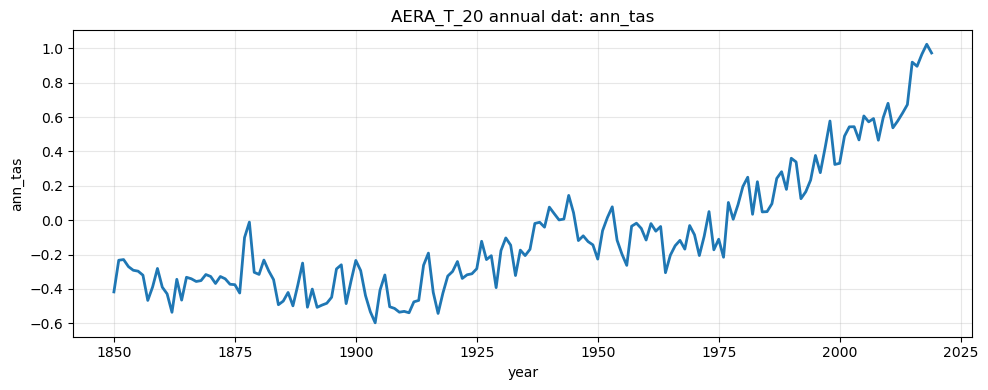

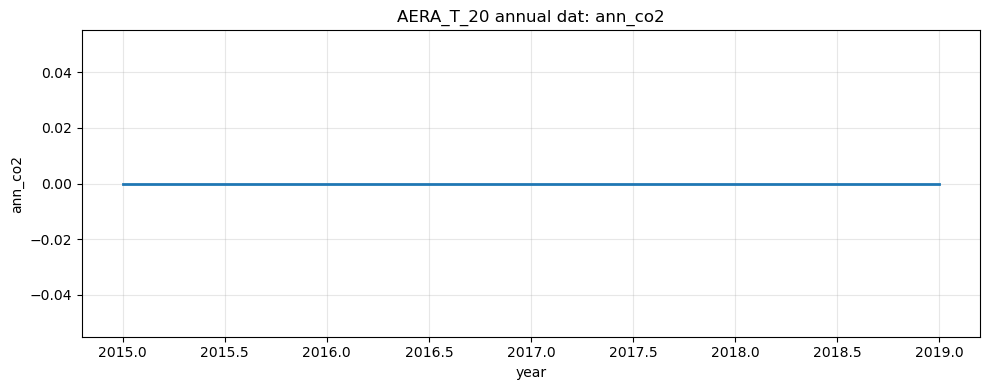

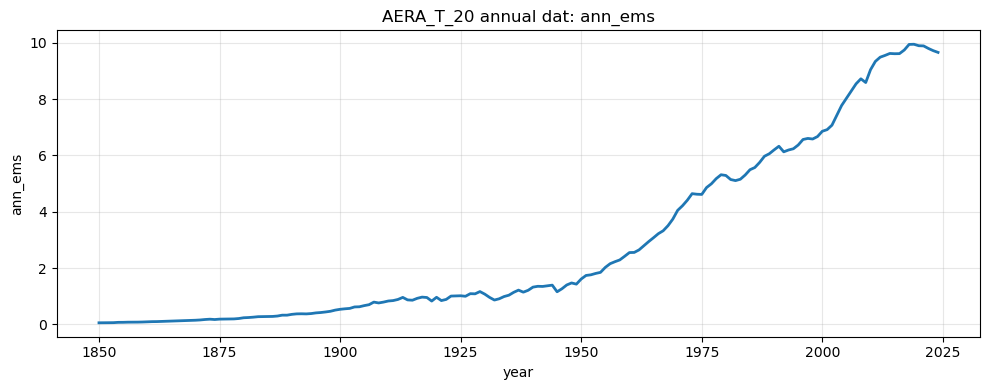


=== Scalar csv ===


,year_stocktake,temp_target_abs,total_emission_budget,ff_emission_budget,reb,ec_cost,ec_reb_diff,ec_overshoot_integral,ec_slope_t1,ec_slope_change,ec_overshoot,ec_curvature,ec_target_year_rel,ec_a,ec_b,ec_c,ec_d
0,2019,1.643,1183.967,861.014,443.255,0.007,2.955,0.0,-0.034,0.0,0.0,0.007,66.0,0.000089,-0.008596,-0.025285,13.593628



=== Meta timeseries csv ===


,year_stocktake,year,total_emission,ff_emission,temp_anth,temp_anth_rel
0,2019,1751,0.003,NaN,NaN,NaN
1,2019,1752,0.003,NaN,NaN,NaN
2,2019,1753,0.003,NaN,NaN,NaN
3,2019,1754,0.003,NaN,NaN,NaN
4,2019,1755,0.003,NaN,NaN,NaN


Index(['year_stocktake', 'year', 'total_emission', 'ff_emission', 'temp_anth',
       'temp_anth_rel'],
      dtype='object')


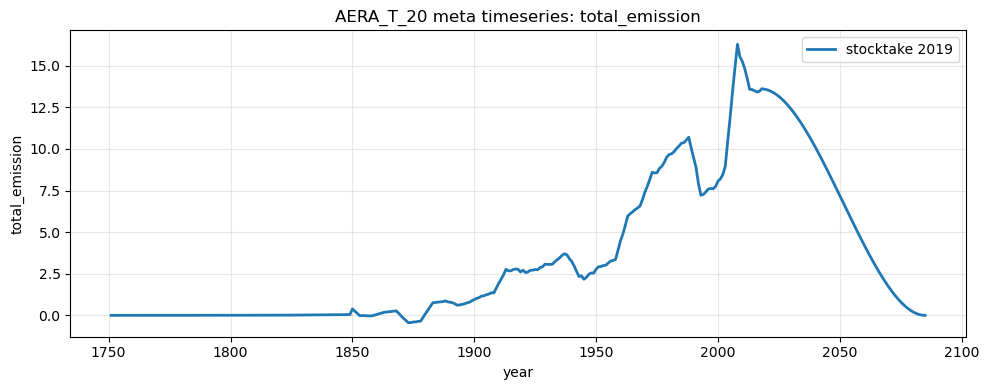

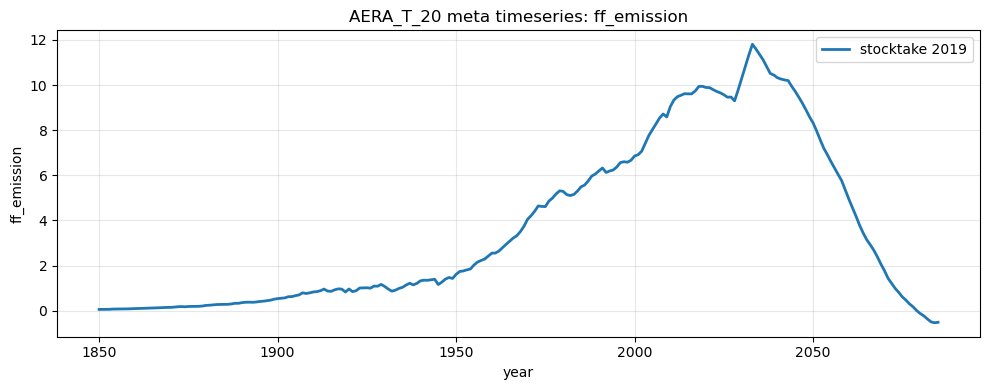

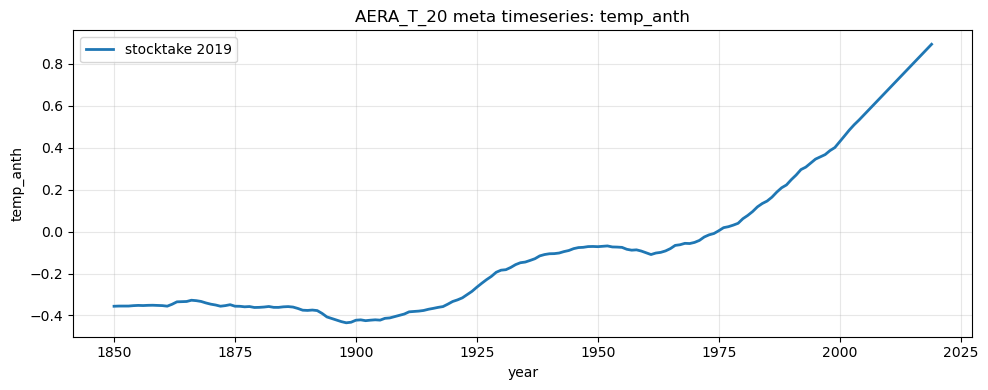

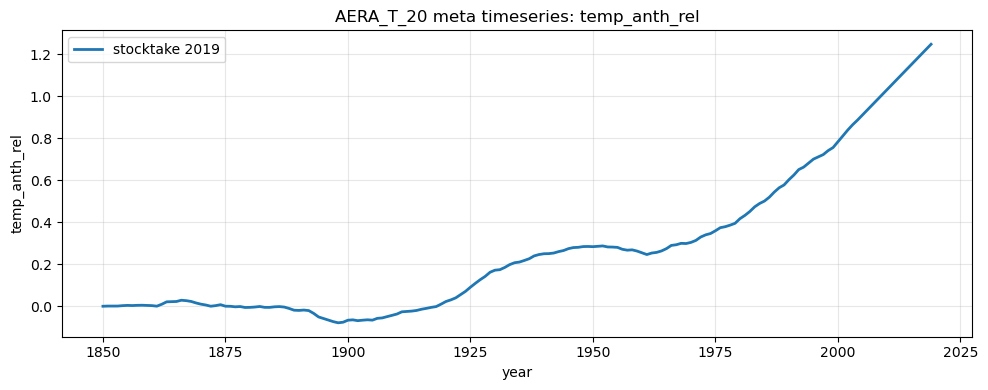


=== Meta NetCDF ===


<xarray.Dataset>
Dimensions:                (year_stocktake: 1, year: 335)
Coordinates:
  * year_stocktake         (year_stocktake) int64 2019
  * year                   (year) int64 1751 1752 1753 1754 ... 2083 2084 2085
Data variables: (12/20)
    total_emission         (year_stocktake, year) float64 ...
    ff_emission            (year_stocktake, year) float64 ...
    temp_anth              (year_stocktake, year) float64 ...
    temp_anth_rel          (year_stocktake, year) float64 ...
    temp_target_abs        (year_stocktake) object ...
    total_emission_budget  (year_stocktake) object ...
    ...                     ...
    ec_curvature           (year_stocktake) object ...
    ec_target_year_rel     (year_stocktake) object ...
    ec_a                   (year_stocktake) float64 ...
    ec_b                   (year_stocktake) float64 ...
    ec_c                   (year_stocktake) float64 ...
    ec_d                   (year_stocktake) float64 ...


--- total_emission ---
<xarray.DataArray 'total_emission' (year_stocktake: 1, year: 335)>
[335 values with dtype=float64]
Coordinates:
  * year_stocktake  (year_stocktake) int64 2019
  * year            (year) int64 1751 1752 1753 1754 ... 2082 2083 2084 2085


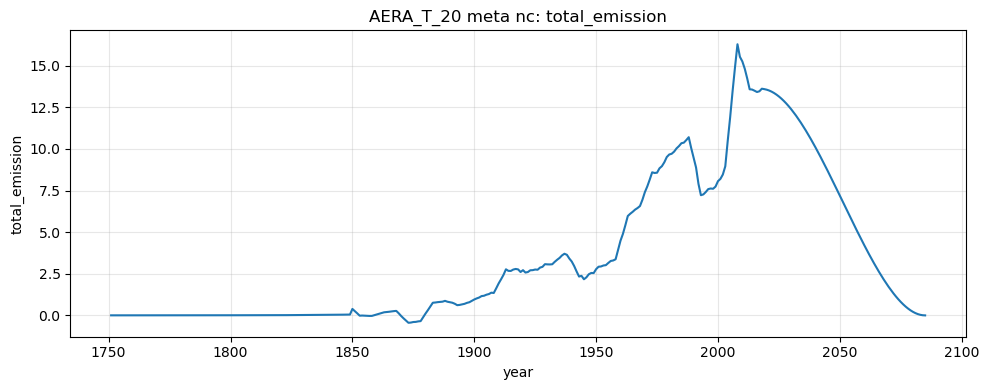


--- ff_emission ---
<xarray.DataArray 'ff_emission' (year_stocktake: 1, year: 335)>
[335 values with dtype=float64]
Coordinates:
  * year_stocktake  (year_stocktake) int64 2019
  * year            (year) int64 1751 1752 1753 1754 ... 2082 2083 2084 2085


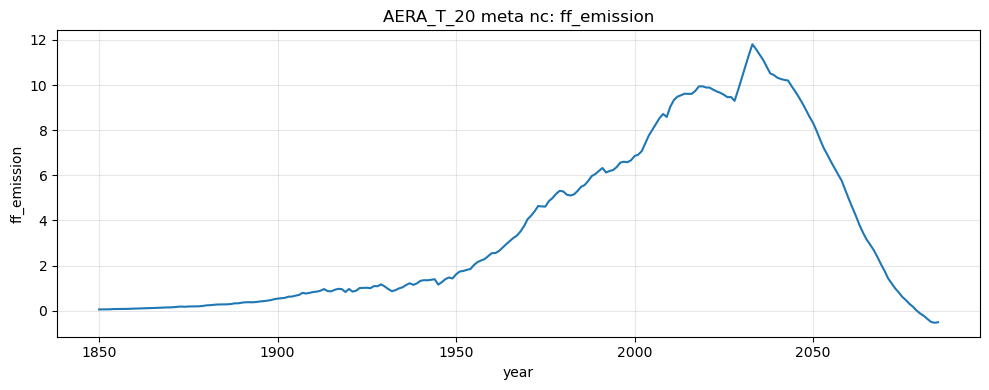


--- temp_anth ---
<xarray.DataArray 'temp_anth' (year_stocktake: 1, year: 335)>
[335 values with dtype=float64]
Coordinates:
  * year_stocktake  (year_stocktake) int64 2019
  * year            (year) int64 1751 1752 1753 1754 ... 2082 2083 2084 2085


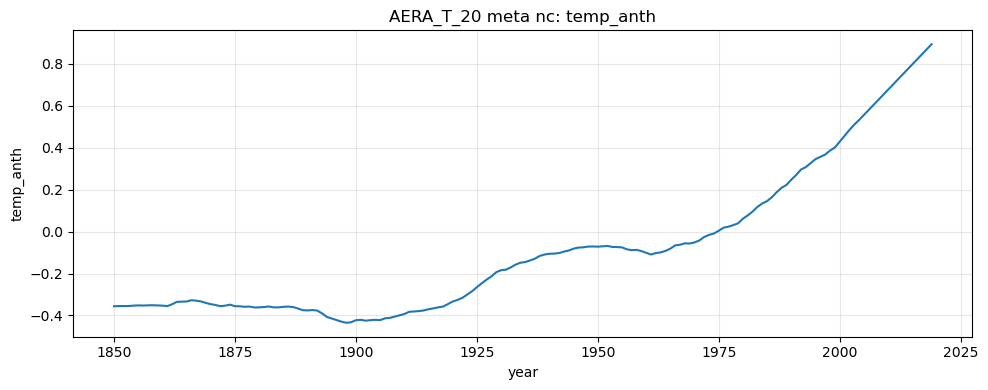


--- temp_anth_rel ---
<xarray.DataArray 'temp_anth_rel' (year_stocktake: 1, year: 335)>
[335 values with dtype=float64]
Coordinates:
  * year_stocktake  (year_stocktake) int64 2019
  * year            (year) int64 1751 1752 1753 1754 ... 2082 2083 2084 2085


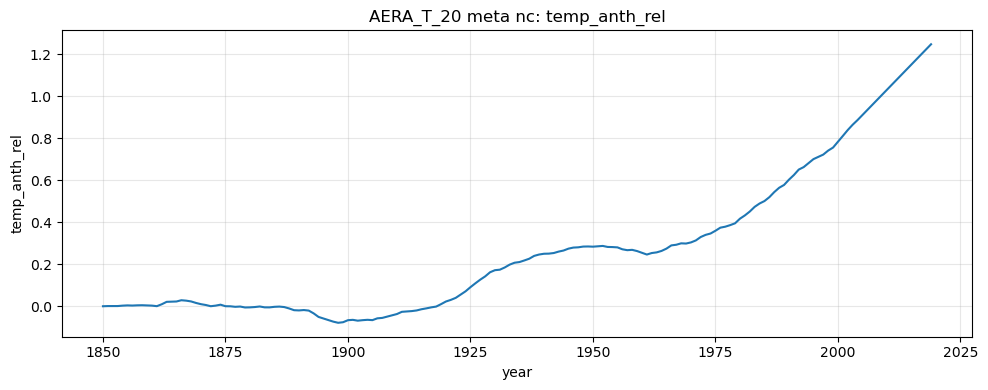


--- temp_target_abs ---
<xarray.DataArray 'temp_target_abs' (year_stocktake: 1)>
[1 values with dtype=object]
Coordinates:
  * year_stocktake  (year_stocktake) int64 2019

--- total_emission_budget ---
<xarray.DataArray 'total_emission_budget' (year_stocktake: 1)>
[1 values with dtype=object]
Coordinates:
  * year_stocktake  (year_stocktake) int64 2019

--- ff_emission_budget ---
<xarray.DataArray 'ff_emission_budget' (year_stocktake: 1)>
[1 values with dtype=object]
Coordinates:
  * year_stocktake  (year_stocktake) int64 2019

--- reb ---
<xarray.DataArray 'reb' (year_stocktake: 1)>
[1 values with dtype=object]
Coordinates:
  * year_stocktake  (year_stocktake) int64 2019

--- ec_cost ---
<xarray.DataArray 'ec_cost' (year_stocktake: 1)>
[1 values with dtype=object]
Coordinates:
  * year_stocktake  (year_stocktake) int64 2019

--- ec_reb_diff ---
<xarray.DataArray 'ec_reb_diff' (year_stocktake: 1)>
[1 values with dtype=object]
Coordinates:
  * year_stocktake  (year_stocktake) int64 201

In [8]:
from pathlib import Path
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

OUT_DIR = Path("/nird/datalake/NS2980K/users/yongyub/O2_linearlity/TipESM/cmor/esm-up2p0/v20251010/AERA/output")

AERAid = "AERA_T_20"
TAG = "1782898285"

files = {
    "csv": OUT_DIR / f"{AERAid}_2019.csv",
    "ann_dat": OUT_DIR / f"{AERAid}_ann_tas_co2_ems.dat",
    "meta_nc": OUT_DIR / f"{AERAid}_meta_{TAG}.nc",
    "scalar": OUT_DIR / f"{AERAid}_meta_{TAG}.nc.scalar.csv",
    "timeseries": OUT_DIR / f"{AERAid}_meta_{TAG}.nc.timeseries.csv",
}

print("=== File check ===")
for k, f in files.items():
    print(f"{k:12s}: {f.exists()}  {f}")

# ============================================================
# Helper plotting function
# ============================================================
def plot_numeric_columns(df, title_prefix, x_candidates=("year", "Year")):
    display(df.head())
    print(df.columns)

    xcol = None
    for c in x_candidates:
        if c in df.columns:
            xcol = c
            break

    if xcol is None:
        xcol = df.columns[0]

    for col in df.columns:
        if col == xcol:
            continue
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue

        plt.figure(figsize=(10, 4))
        plt.plot(df[xcol], df[col], lw=2)
        plt.xlabel(xcol)
        plt.ylabel(col)
        plt.title(f"{title_prefix}: {col}")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

# ============================================================
# 1. AERA csv
# ============================================================
print("\n=== AERA csv ===")
df_csv = pd.read_csv(files["csv"])
plot_numeric_columns(df_csv, f"{AERAid} csv")

# ============================================================
# 2. Annual dat
# ============================================================
print("\n=== Annual dat ===")
import pickle
import pandas as pd

with open(files["ann_dat"], "rb") as f:
    year, ann_tas, ann_co2, ann_ems = pickle.load(f)

df_ann = pd.DataFrame({
    "year": year,
    "ann_tas": ann_tas,
    "ann_co2": ann_co2,
    "ann_ems": ann_ems,
})

plot_numeric_columns(df_ann, f"{AERAid} annual dat")

# ============================================================
# 3. Scalar csv
# ============================================================
print("\n=== Scalar csv ===")
df_scalar = pd.read_csv(files["scalar"])
display(df_scalar)

# ============================================================
# 4. Meta timeseries csv
# ============================================================
print("\n=== Meta timeseries csv ===")
df_ts = pd.read_csv(files["timeseries"])
display(df_ts.head())
print(df_ts.columns)

for col in df_ts.columns:
    if col in ["year", "year_stocktake"]:
        continue
    if not pd.api.types.is_numeric_dtype(df_ts[col]):
        continue

    plt.figure(figsize=(10, 4))

    if "year_stocktake" in df_ts.columns:
        for stocktake, sub in df_ts.groupby("year_stocktake"):
            plt.plot(sub["year"], sub[col], lw=2, label=f"stocktake {stocktake}")
        plt.legend()
    else:
        plt.plot(df_ts["year"], df_ts[col], lw=2)

    plt.xlabel("year")
    plt.ylabel(col)
    plt.title(f"{AERAid} meta timeseries: {col}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ============================================================
# 5. Meta NetCDF
# ============================================================
print("\n=== Meta NetCDF ===")
ds = xr.open_dataset(files["meta_nc"])
display(ds)

for var in ds.data_vars:
    da = ds[var]
    print(f"\n--- {var} ---")
    print(da)

    if "year" not in da.dims:
        continue

    plt.figure(figsize=(10, 4))

    if "year_stocktake" in da.dims:
        da.plot(hue="year_stocktake")
    else:
        da.plot()

    plt.title(f"{AERAid} meta nc: {var}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

<xarray.Dataset>
Dimensions:    (time: 1056, bnds: 2, lon: 144, lat: 96)
Coordinates:
  * time       (time) object 2014-01-16 00:00:00 ... 2101-12-16 00:00:00
  * lon        (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat        (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object ...
    CO2_flux   (time, lat, lon) float32 ...
    date       (time) int32 ...
Attributes: (12/18)
    CDI:                       Climate Data Interface version 1.9.10 (https:/...
    Conventions:               CF-1.6
    data_title:                Future anthropogenic emissions of CO2 prepared...
    data_summary:              conservatively regridded from input4MIPs files...
    source_files:              CO2-em-anthro_input4MIPs_emissions_ScenarioMIP...
    data_creator:              Keith Lindsay (klindsay@ucar.edu)
    ...                        ...
    CDO:                       Clima

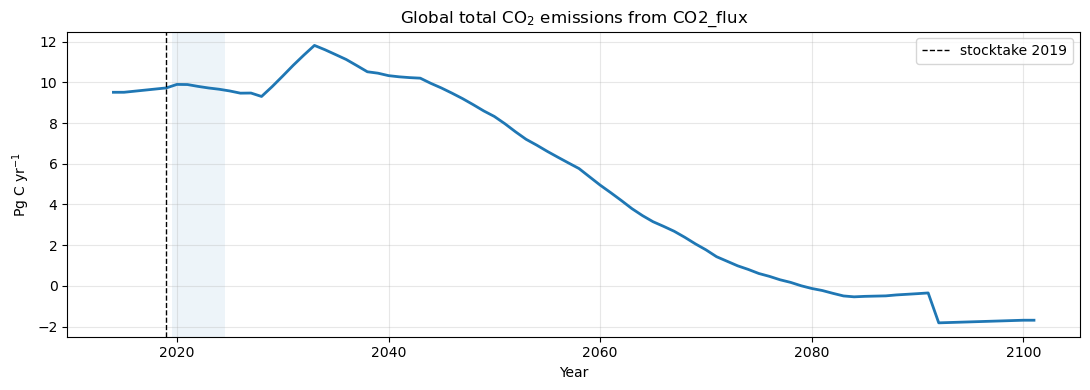

,Annual CO2 emissions
year,
2014,9.509083
2015,9.509562
2016,9.563086
2017,9.616611
2018,9.670135
2019,9.723660
2020,9.895275
2021,9.889152
2022,9.798306


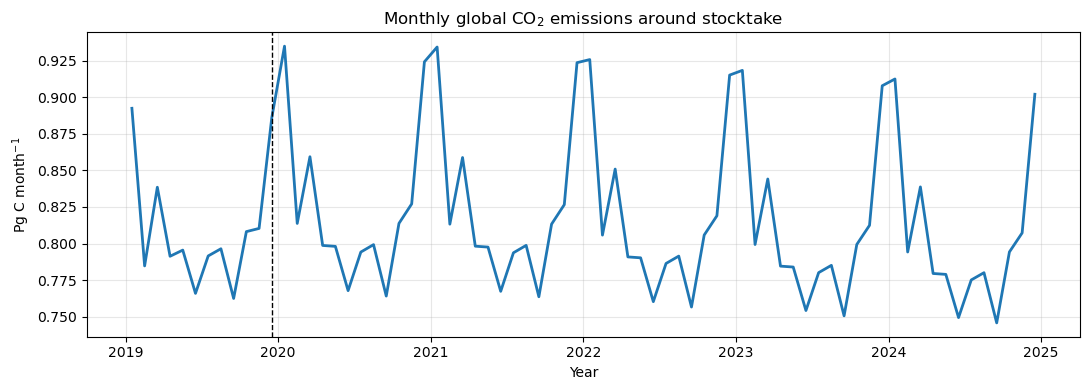

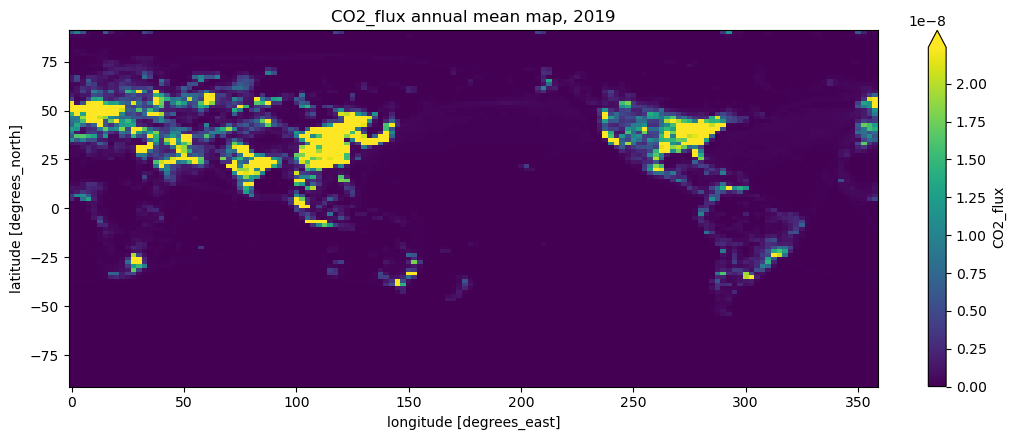

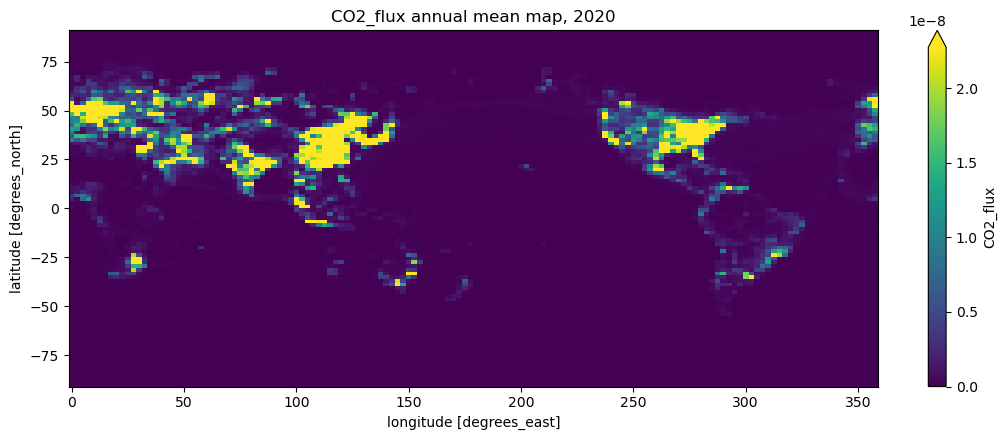

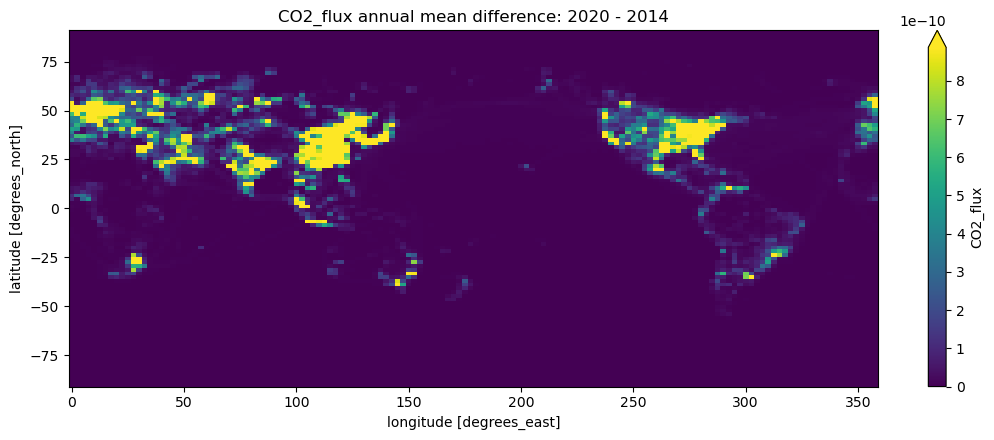

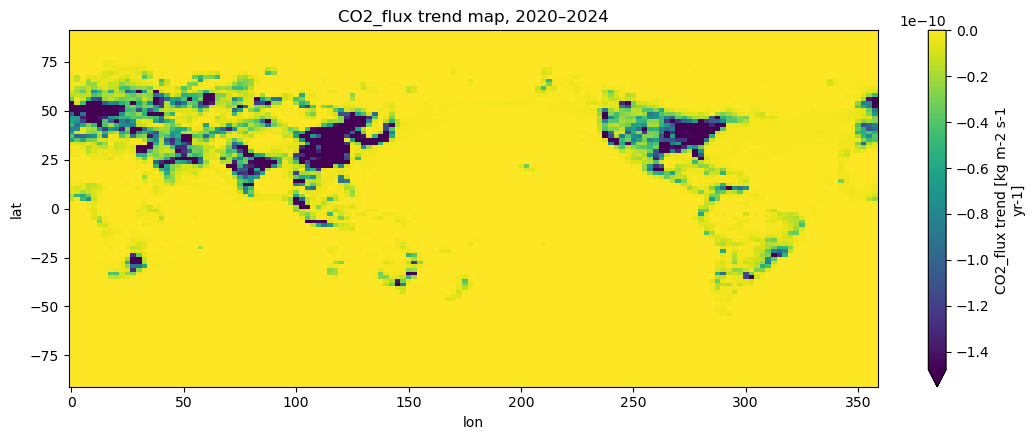

2020: mean spatial std of monthly ratio = 1.193e-07
2021: mean spatial std of monthly ratio = 2.385e-07
2022: mean spatial std of monthly ratio = 2.664e-09
2023: mean spatial std of monthly ratio = 1.192e-07
2024: mean spatial std of monthly ratio = 1.192e-07


In [11]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Settings
# ============================================================
FN = Path(
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010/AERA/emissions/"
    "emissions-cmip6_CO2_anthro_surface_AERA_T_20_2020-2024_201401-220112_fv_1.9x2.5.nc"
)

stocktake_yr = 2019
replace_years = np.arange(2020, 2025)

# ============================================================
# Open
# ============================================================
ds = xr.open_dataset(FN, decode_times=True, use_cftime=True)
co2 = ds["CO2_flux"]  # kg m-2 s-1

print(ds)
print(co2)

# ============================================================
# Area weights
# ============================================================
lat = ds["lat"]
lon = ds["lon"]

# regular lon-lat grid: area proportional to cos(lat)
wlat = np.cos(np.deg2rad(lat))
area_weights = wlat.broadcast_like(co2.isel(time=0))

# Approximate Earth surface area normalization
earth_area = 5.1e14  # m2
area = area_weights / area_weights.sum(dim=("lat", "lon")) * earth_area

# ============================================================
# Monthly global total emissions
# kg CO2 m-2 s-1 -> Pg C month-1
# ============================================================
sec_per_month = ds["time"].dt.days_in_month * 24 * 3600
kgco2_to_pgc = 12.0 / 44.0 * 1e-12

emis_mon = (co2 * area).sum(("lat", "lon")) * sec_per_month * kgco2_to_pgc
emis_mon.name = "CO2 emissions"
emis_mon.attrs["units"] = "Pg C month-1"

emis_ann = emis_mon.groupby("time.year").sum("time")
emis_ann.name = "Annual CO2 emissions"
emis_ann.attrs["units"] = "Pg C yr-1"

# ============================================================
# 1. Annual global emission time series
# ============================================================
plt.figure(figsize=(11, 4))
plt.plot(emis_ann["year"], emis_ann, lw=2)
plt.axvline(stocktake_yr, ls="--", color="k", lw=1, label=f"stocktake {stocktake_yr}")
for yy in replace_years:
    plt.axvspan(yy - 0.5, yy + 0.5, alpha=0.08)

plt.xlabel("Year")
plt.ylabel("Pg C yr$^{-1}$")
plt.title("Global total CO$_2$ emissions from CO2_flux")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

display(emis_ann.sel(year=slice(2014, 2025)).to_dataframe())

# ============================================================
# 2. Monthly global emission time series around stocktake
# ============================================================
emis_mon_sel = emis_mon.sel(time=slice(f"{stocktake_yr}-01-01", "2024-12-31"))

x_mon = (
    emis_mon_sel["time"].dt.year.values
    + (emis_mon_sel["time"].dt.month.values - 0.5) / 12.0
)

plt.figure(figsize=(11, 4))
plt.plot(x_mon, emis_mon_sel.values, lw=2)
plt.axvline(stocktake_yr + 11.5/12.0, ls="--", color="k", lw=1)
plt.xlabel("Year")
plt.ylabel("Pg C month$^{-1}$")
plt.title("Monthly global CO$_2$ emissions around stocktake")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 3. Stocktake-year annual mean spatial map
# ============================================================
map_stocktake = co2.sel(time=slice(f"{stocktake_yr}-01-01", f"{stocktake_yr}-12-31")).mean("time")

plt.figure(figsize=(11, 4.5))
map_stocktake.plot(x="lon", y="lat", robust=True)
plt.title(f"CO2_flux annual mean map, {stocktake_yr}")
plt.tight_layout()
plt.show()

# ============================================================
# 4. First replacement-year annual mean spatial map
# ============================================================
map_2020 = co2.sel(time=slice("2020-01-01", "2020-12-31")).mean("time")

plt.figure(figsize=(11, 4.5))
map_2020.plot(x="lon", y="lat", robust=True)
plt.title("CO2_flux annual mean map, 2020")
plt.tight_layout()
plt.show()

# ============================================================
# 5. Difference map: 2020 - 2014
# ============================================================
map_2014 = co2.sel(time=slice("2014-01-01", "2014-12-31")).mean("time")
diff_2020_2014 = map_2020 - map_2014

plt.figure(figsize=(11, 4.5))
diff_2020_2014.plot(x="lon", y="lat", robust=True)
plt.title("CO2_flux annual mean difference: 2020 - 2014")
plt.tight_layout()
plt.show()

# ============================================================
# 6. Trend map for replacement years: 2020-2024
# Units: kg m-2 s-1 yr-1
# ============================================================
co2_ann_map = co2.groupby("time.year").mean("time")
co2_rep = co2_ann_map.sel(year=replace_years)

trend = co2_rep.polyfit(dim="year", deg=1)["polyfit_coefficients"].sel(degree=1)
trend.name = "CO2_flux trend"
trend.attrs["units"] = "kg m-2 s-1 yr-1"

plt.figure(figsize=(11, 4.5))
trend.plot(x="lon", y="lat", robust=True)
plt.title("CO2_flux trend map, 2020–2024")
plt.tight_layout()
plt.show()

# ============================================================
# 7. Check if spatial pattern is simply scaled from 2014
# Safer selection for cftime calendars
# ============================================================
co2_loaded = co2.load()

def sel_ym(da, yy, mm):
    return da.where(
        (da["time"].dt.year == yy) & (da["time"].dt.month == mm),
        drop=True
    ).isel(time=0)

for yy in replace_years:
    ratios = []

    for mm in range(1, 13):
        a = sel_ym(co2_loaded, yy, mm)
        b = sel_ym(co2_loaded, 2014, mm)

        r = a / b
        r = r.where(np.isfinite(r))

        ratios.append(float(r.std(skipna=True)))

    print(f"{yy}: mean spatial std of monthly ratio = {np.mean(ratios):.3e}")